# AC Stark Shift: Qubit Spectroscopy vs Readout Amplitude
Load `ds_raw.h5` from an AC-Stark qubit-spectroscopy sweep over `readout_amp_ratio`,
run `QubitSpectroscopyAnalyzer` on each slice, and plot the peak frequency vs readout amplitude.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data
from scqat.protocols.qubit_spectroscopy import QubitSpectroscopyAnalyzer

## 1. Configuration

In [2]:
DATA_FOLDER = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\Q1\ng01_ref0165_test04\AC_stark\#3805_LCH_qubit_spectroscopy_vs_ROamp_193549"

DS_RAW_PATH = os.path.join(DATA_FOLDER, "ds_raw.h5")
FIGURE_SAVE_PATH = os.path.join(DATA_FOLDER, "figures")
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)

amp_ref = 0.04
chi_eff = -0.075 *2

## 2. Load Dataset

In [3]:
dataset = load_xarray_h5(DS_RAW_PATH)
# Split by qubit and pick the first one
sq_data = repetition_data(dataset)[0]
# Combine I and Q into complex IQdata
sq_data["IQdata"] = sq_data["I"] + 1j * sq_data["Q"]
print(sq_data)


<xarray.Dataset> Size: 243kB
Dimensions:            (detuning: 301, readout_amp_ratio: 20)
Coordinates:
  * detuning           (detuning) float64 2kB -2.95e+08 -2.94e+08 ... 5e+06
  * readout_amp_ratio  (readout_amp_ratio) float64 160B 0.0 0.1 0.2 ... 1.8 1.9
    qubit              <U2 8B 'q1'
Data variables:
    I1                 (readout_amp_ratio, detuning) int32 24kB 0 0 0 ... 0 0 0
    Q1                 (readout_amp_ratio, detuning) int32 24kB 0 0 0 ... 0 0 0
    I                  (readout_amp_ratio, detuning) float64 48kB -0.00205 .....
    Q                  (readout_amp_ratio, detuning) float64 48kB -0.001485 ....
    IQdata             (readout_amp_ratio, detuning) complex128 96kB (-0.0020...


## 3. 2D Overview Plot (raw signal vs detuning and readout_amp_ratio)

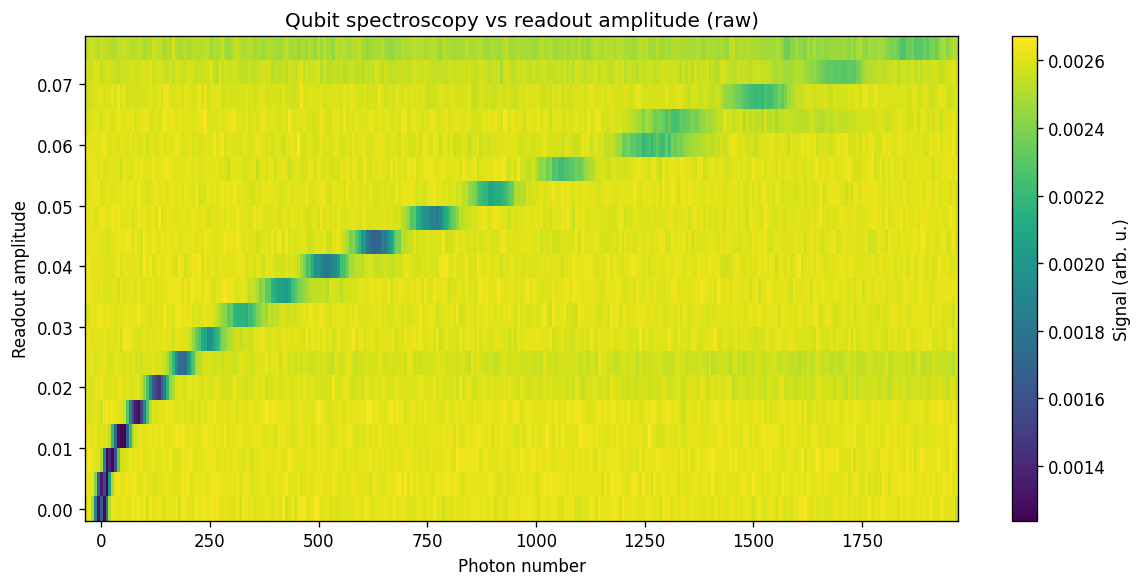

In [4]:
detuning = sq_data.coords["detuning"].values
ro_amp = sq_data.coords["readout_amp_ratio"].values

# Scale by amp_ref if provided
if amp_ref is not None:
    ro_amp = ro_amp * amp_ref

ro_amp_label = "Readout amplitude" if amp_ref is not None else "Readout amplitude ratio"

# Detuning axis: convert to photon number if chi_eff is provided
if chi_eff is not None:
    det_axis = detuning / 1e6 / chi_eff
    det_axis_label = "Photon number"
else:
    det_axis = detuning / 1e6
    det_axis_label = "Detuning (MHz)"

# Build 2D signal from complex IQdata
signal_2d = np.abs(sq_data["IQdata"].values)

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
im = ax.pcolormesh(
    det_axis, ro_amp, signal_2d,
    shading="auto", cmap="viridis",
)
ax.set_xlabel(det_axis_label)
ax.set_ylabel(ro_amp_label)
ax.set_title("Qubit spectroscopy vs readout amplitude (raw)")
fig.colorbar(im, ax=ax, label="Signal (arb. u.)")
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_SAVE_PATH, "ac_stark_2d_raw.png"), bbox_inches="tight")
plt.show()


## 4. Run QubitSpectroscopyAnalyzer per readout_amp_ratio

In [5]:
analyzer = QubitSpectroscopyAnalyzer()

peak_detunings = []
peak_freqs = []
peak_ro_amps = []

for i, amp in enumerate(sq_data.coords["readout_amp_ratio"].values):
    # Select single readout_amp_ratio slice
    slice_ds = sq_data.sel(readout_amp_ratio=amp)

    results, _ = analyzer.analyze(slice_ds, skip_figures=True, max_peaks=1)

    amp_scaled = float(amp) * amp_ref if amp_ref is not None else float(amp)

    if len(results["peaks"]) == 1:
        pk = results["peaks"][0]
        peak_detunings.append(pk["detuning"])
        peak_freqs.append(pk.get("full_freq", np.nan))
        peak_ro_amps.append(amp_scaled)
    else:
        peak_detunings.append(np.nan)
        peak_freqs.append(np.nan)
        peak_ro_amps.append(amp_scaled)

peak_detunings = np.array(peak_detunings)
peak_freqs = np.array(peak_freqs)
peak_ro_amps = np.array(peak_ro_amps)

print(f"Peaks found in {np.isfinite(peak_detunings).sum()} / {len(ro_amp)} slices")

Peaks found in 20 / 20 slices


## 5. 2D Plot with Peak Overlay

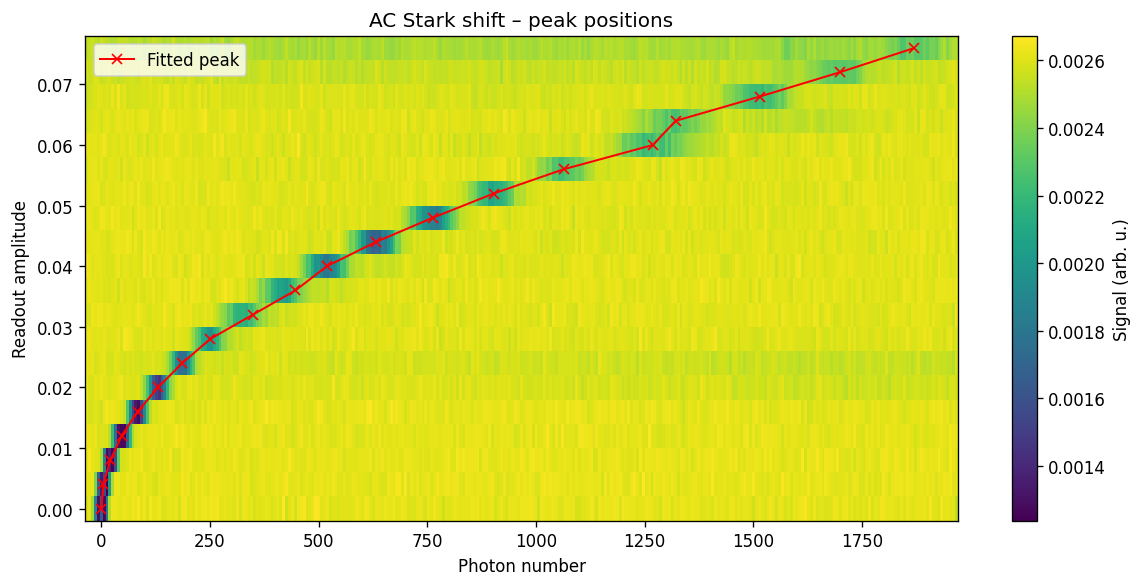

In [6]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
im = ax.pcolormesh(
    det_axis, ro_amp, signal_2d,
    shading="auto", cmap="viridis",
)
# Overlay extracted peaks
mask = np.isfinite(peak_detunings)
peak_det_axis = peak_detunings[mask] / 1e6 / chi_eff if chi_eff is not None else peak_detunings[mask] / 1e6
ax.plot(
    peak_det_axis, peak_ro_amps[mask],
    "rx-", ms=6, lw=1.2, label="Fitted peak",
)
ax.set_xlabel(det_axis_label)
ax.set_ylabel(ro_amp_label)
ax.set_title("AC Stark shift – peak positions")
ax.legend()
fig.colorbar(im, ax=ax, label="Signal (arb. u.)")
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_SAVE_PATH, "ac_stark_2d_peaks.png"), bbox_inches="tight")
plt.show()

## 6. Peak Detuning vs Readout Amplitude Ratio

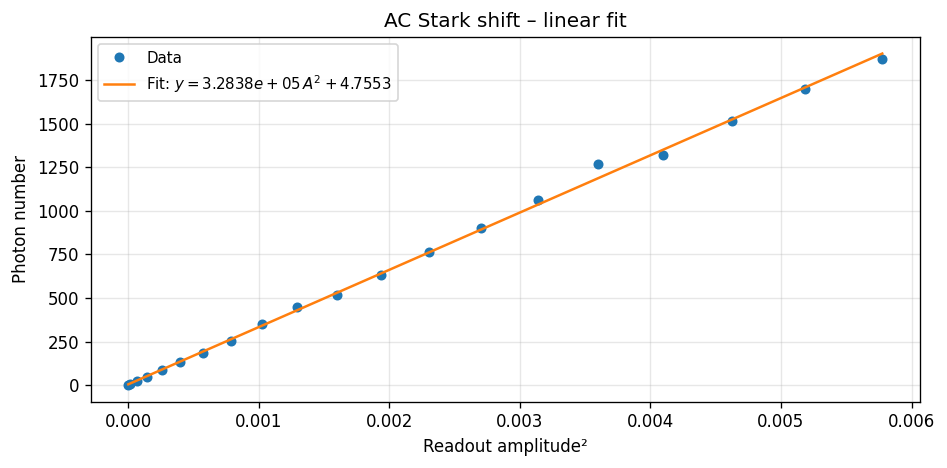

Fit: Photon number = 3.283762e+05 * ro_amp² + 4.755306


In [7]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
mask = np.isfinite(peak_detunings)

# Linear fit: peak_detunings (or photon number) = a * peak_ro_amps^2 + b
x_fit = peak_ro_amps[mask] ** 2
y_fit = peak_detunings[mask] / 1e6 / chi_eff if chi_eff is not None else peak_detunings[mask] / 1e6
coeffs = np.polyfit(x_fit, y_fit, 1)
a, b = coeffs

x_smooth = np.linspace(x_fit.min(), x_fit.max(), 200)
y_smooth = np.polyval(coeffs, x_smooth)

ax.plot(x_fit, y_fit, "o", ms=5, label="Data")
ax.plot(x_smooth, y_smooth, "-", lw=1.5, color="C1",
        label=f"Fit: $y = {a:.4e}\\, A^2 + {b:.4f}$")
ax.set_xlabel(ro_amp_label + "²")
ax.set_ylabel(det_axis_label)
ax.set_title("AC Stark shift – linear fit")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_SAVE_PATH, "ac_stark_peak_vs_ro_amp.png"), bbox_inches="tight")
plt.show()

print(f"Fit: {det_axis_label} = {a:.6e} * ro_amp² + {b:.6f}")

## 7. Peak Summary

In [8]:
print(f"{'RO amp ratio':>14s}  {'Peak detuning (MHz)':>20s}  {'Peak freq (GHz)':>16s}")
print("-" * 56)
for amp, det, freq in zip(peak_ro_amps, peak_detunings, peak_freqs):
    det_str = f"{det / 1e6:.3f}" if np.isfinite(det) else "no peak"
    freq_str = f"{freq / 1e9:.6f}" if np.isfinite(freq) else "—"
    print(f"{amp:14.4f}  {det_str:>20s}  {freq_str:>16s}")

  RO amp ratio   Peak detuning (MHz)   Peak freq (GHz)
--------------------------------------------------------
        0.0000                -0.050                 —
        0.0040                -0.782                 —
        0.0080                -3.187                 —
        0.0120                -7.094                 —
        0.0160               -12.608                 —
        0.0200               -19.633                 —
        0.0240               -27.978                 —
        0.0280               -37.641                 —
        0.0320               -52.321                 —
        0.0360               -66.982                 —
        0.0400               -77.879                 —
        0.0440               -94.746                 —
        0.0480              -114.398                 —
        0.0520              -135.403                 —
        0.0560              -159.493                 —
        0.0600              -190.248                 —
        

## 8. Package Results as xarray Dataset

In [9]:
mask = np.isfinite(peak_detunings)

ds_result = xr.Dataset(
    {
        "IQdata": sq_data["IQdata"],
        "peak_detuning": xr.DataArray(peak_detunings[mask], dims="peak"),
        "peak_ro_amp": xr.DataArray(peak_ro_amps[mask], dims="peak"),
        "fit_x": xr.DataArray(x_smooth, dims="fit_point"),
        "fit_y": xr.DataArray(y_smooth, dims="fit_point"),
    },
    attrs={
        "amp_ref": amp_ref,
        "chi_eff": chi_eff,
        "fit_coeff_a": a,
        "fit_coeff_b": b,
    },
)

print(ds_result)

ds_result.to_netcdf(os.path.join("temp_output", "ac_stark_result.h5"), engine="h5netcdf")

<xarray.Dataset> Size: 102kB
Dimensions:            (detuning: 301, readout_amp_ratio: 20, peak: 20,
                        fit_point: 200)
Coordinates:
  * detuning           (detuning) float64 2kB -2.95e+08 -2.94e+08 ... 5e+06
  * readout_amp_ratio  (readout_amp_ratio) float64 160B 0.0 0.1 0.2 ... 1.8 1.9
    qubit              <U2 8B 'q1'
Dimensions without coordinates: peak, fit_point
Data variables:
    IQdata             (readout_amp_ratio, detuning) complex128 96kB (-0.0020...
    peak_detuning      (peak) float64 160B -4.955e+04 -7.819e+05 ... -2.804e+08
    peak_ro_amp        (peak) float64 160B 0.0 0.004 0.008 ... 0.068 0.072 0.076
    fit_x              (fit_point) float64 2kB 0.0 2.903e-05 ... 0.005776
    fit_y              (fit_point) float64 2kB 4.755 14.29 ... 1.901e+03
Attributes:
    amp_ref:      0.04
    chi_eff:      -0.15
    fit_coeff_a:  328376.2109395182
    fit_coeff_b:  4.755306265216912
